# Redes Neuronales Convolucionales

En posts anteriores hemos presentado varias arquitecturas diferentes de `redes neuronales`. Algunos ejemplos son el [`Perceptrón Multicapa`](https://sensioai.com/blog/023_mlp_backprop) o las [`redes neuronales recurrentes`](https://sensioai.com/blog/034_rnn_intro), las cuales hemos aplicado para [predicción de series temporales](https://sensioai.com/blog/035_rnn_forecast) y varias aplicaciones de [lenguaje](https://sensioai.com/blog/038_clasificacion_texto). En este post vamos a presentar una nueva arquitectura de `red neuronal` conocida como `red neuronal convolucional`, especialmente diseñada para trabajar con imágenes.

## Introducción

Las `redes neuronales convolucionales` (CNNs) surgieron del estudio del córtex visual del cerebro y se han utilizado en el reconocimiento de imágenes desde la década de los 80. En los últimos años, gracias al aumento de la potencia computacional, la cantidad de datos de entrenamiento disponibles y los trucos ya explicados anteriormente para entrenar redes profundas, las CNNs han logrado lograr un rendimiento sobrehumano en algunas tareas visuales complejas. Este tipo de red se puede encontrar en servicios de búsqueda de imágenes, coches autónomos, sistemas de clasificación de vídeo automático y muchas otras aplicaciones. Además, las CNNs no se limitan a la percepción visual, también tienen éxito en tareas como el reconocimiento de voz y el procesamiento de datos tridimensionales.

### El córtex visual

Las neuronas del córtex visual tienen un pequeño *campo receptivo local*, lo que significa que reaccionan solo a los estímulos visuales ubicados en una región limitada del campo visual. Los campos receptivos de diferentes neuronas pueden superponerse y juntos forman el campo visual completo.

![](https://mymlpics.s3.eu-de.cloud-object-storage.appdomain.cloud/visual_cortex.png)

Las neuronas de las primeras capas del córtex visual reaccionan solo ante ciertos patrones simples, como por ejemplo líneas horizontales mientras que otras reaccionan a líneas verticales (dos neuronas pueden tener el mismo campo receptivo pero reaccionan a diferentes orientaciones de línea). En las capas siguientes, las neuronas tienen campos receptivos más grandes y reaccionan a patrones más complejos, que pueden ser combinaciones de patrones de nivel inferior, construyendo de esta manera una jerarquía en diferentes capas que resultan finalmente en las formas y colores que vemos.

Basándose en estos conceptos, Yann LeCunn introdujo las CNNs en 1998 en la famosa arquitectura [LeNet-5](https://colab.research.google.com/drive/1fqxaTs-Ux9KQHyCJsToFTZwSNoHv9rKe#scrollTo=CMK6qB1EdfqC), utilizada por los bancos para reconocer de manera automática los números manuscritos en cheques para un procesamiento más rápido.

## La Capa Convolucional

Como veremos más adelante, las `redes convolucionales` están formadas por varias capas con diferente responsabilidad. De entre estas capas, la más importante es la `capa convolucional` la cual es responsable de identificar y construir las diferentes formas, colores y texturas de manera similar al córtex visual. Para llevar a cabo esta tarea usaremos un conjunto de *filtros* (también llamados *kernels*) los cuales deslizaremos por toda la imagen aplicando la operación *convolución*. Esta operación consiste en aplicar el producto escalar entre el filtro y los píxeles de la imagen cubiertos por el filtro, lo que se conoce como el *campo receptivo* (o *receptive field*). En el siguiente gif puedes ver esta operación en acción, en la que tenemos un filtro de 3x3 el cual deslizamos por nuestra imagen, la cual tiene una resolución de 5x5. Para cada posible posición del filtro dentro de la imagen, calculamos el producto de cada pixel por el valor del filtro correspondiente y guardamos el resultado en el mapa de salida.

![](https://miro.medium.com/max/1052/1*GcI7G-JLAQiEoCON7xFbhg.gif)

En este segundo ejemplo estamos aplicando la misma operación, pero ahora en el caso de que nuestra imagen tenga 3 canales (una imagen en color RGB). En este caso, nuestros filtros también tienen 3 canales. Además estamos aplicando más de un filtro, lo cual resulta en número de canales en el mapa de salida igual al número de filtros utilizados.

![](https://cdn-media-1.freecodecamp.org/images/gb08-2i83P5wPzs3SL-vosNb6Iur5kb5ZH43)

Vamos a ver un ejemplo de aplicación con imágenes reales, en este caso con imágenes del dataset CIFAR10 con el cual ya hemos trabajado anteriormente.

In [14]:
import sys
print(sys.executable)

c:\Users\LENOVO LOQ\Documents\IA2\.venv\Scripts\python.exe


In [15]:
import torch
import torchvision

device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.10.0+cu126
12.6
True


In [16]:
device

'cuda'

In [17]:
import random
import os
import shutil

dataset_path = "C:/Users/LENOVO LOQ/Documents/IA2/Apparel"
output_path = "C:/Users/LENOVO LOQ/Documents/IA2/Apparel_split"
train_ratio = 0.8

for label in os.listdir(dataset_path):

    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    images = os.listdir(label_path)
    random.shuffle(images)

    split_index = int(len(images) * train_ratio )

    train_images = images[:split_index]
    test_images = images[split_index:]

    os.makedirs(os.path.join(output_path, "train", label), exist_ok=True)
    os.makedirs(os.path.join(output_path, "test", label), exist_ok=True)

    for img in train_images:
        shutil.copy(
            os.path.join(label_path, img),
            os.path.join(output_path, "train", label, img)
        )
    
    for img in test_images:
        shutil.copy(
            os.path.join(label_path, img),
            os.path.join(output_path, "test", label, img)
        )

print("Data dividido correctamente")

Data dividido correctamente


In [18]:
train_path = "C:/Users/LENOVO LOQ/Documents/IA2/Apparel_split/train"
test_path = "C:/Users/LENOVO LOQ/Documents/IA2/Apparel_split/test"

for label in os.listdir(train_path):
    train_count = len(os.listdir(os.path.join(train_path,label)))
    test_count = len(os.listdir(os.path.join(test_path,label)))

    print(label)
    print("train:", train_count)
    print("test:", test_count)

black_dress
train: 775
test: 166
black_pants
train: 836
test: 311
black_shirt
train: 819
test: 262
black_shoes
train: 820
test: 274
black_shorts
train: 752
test: 119
blue_dress
train: 781
test: 183
blue_pants
train: 827
test: 287
blue_shirt
train: 813
test: 262
blue_shoes
train: 770
test: 178
blue_shorts
train: 752
test: 114


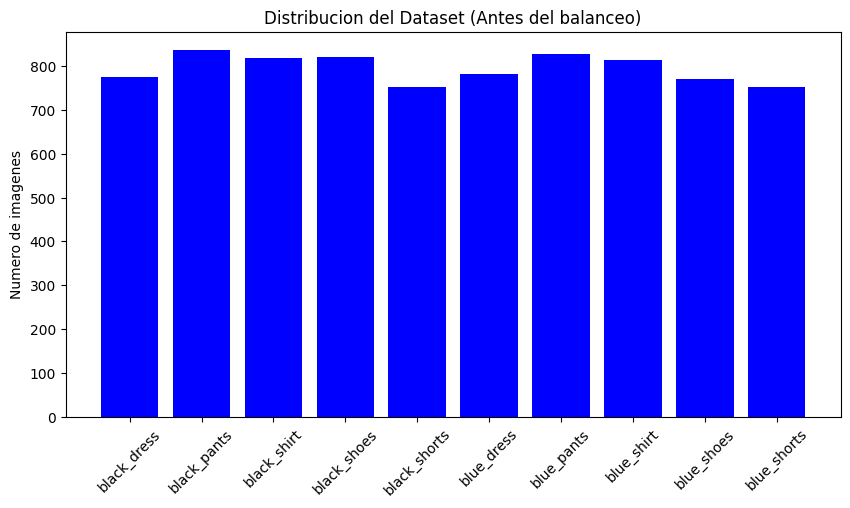

In [19]:
import matplotlib.pyplot as plt
dataset_path = "C:/Users/LENOVO LOQ/Documents/IA2/Apparel_split/train"

labels = []
counts = []

for label in os.listdir(dataset_path):

    label_path = os.path.join(dataset_path, label)

    if os.path.isdir(label_path):
        
        num_images = len(os.listdir(label_path))
        labels.append(label)
        counts.append(num_images)

plt.figure(figsize=(10, 5))
plt.bar(labels, counts, color= 'blue')
plt.xticks(rotation=45)
plt.title('Distribucion del Dataset (Antes del balanceo)')
plt.ylabel('Numero de imagenes')
plt.show()


Usaremos data Augmentation para balancear el dataSet


In [20]:
from PIL import Image
from torchvision import transforms

dataset_path = "C:/Users/LENOVO LOQ/Documents/IA2/Apparel_split/train"

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
])

target_size = 700

for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label) 
    images = os.listdir(label_path)

    while len(images) < target_size:
        img_name = random.choice(images)

        img_path = os.path.join(label_path, img_name)
        img = Image.open(img_path)
        aug_img = augment(img)
        new_name = f"aug_{random.randint(0, 100000)}.jpg"
        aug_img.save(os.path.join(label_path, new_name))
        images.append(new_name)

    print(label, "->", len(images))

black_dress -> 775
black_pants -> 836
black_shirt -> 819
black_shoes -> 820
black_shorts -> 752
blue_dress -> 781
blue_pants -> 827
blue_shirt -> 813
blue_shoes -> 770
blue_shorts -> 752


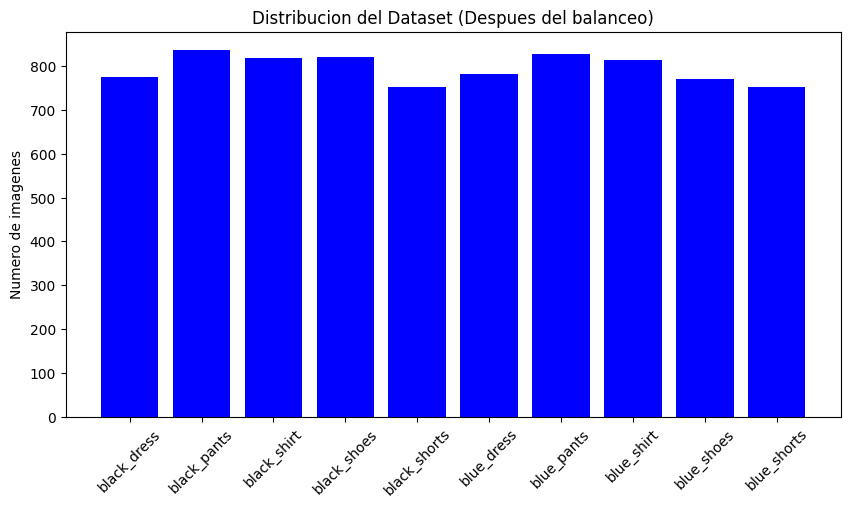

In [21]:
import matplotlib.pyplot as plt
dataset_path = "C:/Users/LENOVO LOQ/Documents/IA2/Apparel_split/train"

labels = []
counts = []

for label in os.listdir(dataset_path):

    label_path = os.path.join(dataset_path, label)

    if os.path.isdir(label_path):
        
        num_images = len(os.listdir(label_path))
        labels.append(label)
        counts.append(num_images)

plt.figure(figsize=(10, 5))
plt.bar(labels, counts, color= 'blue')
plt.xticks(rotation=45)
plt.title('Distribucion del Dataset (Despues del balanceo)')
plt.ylabel('Numero de imagenes')
plt.show()


In [26]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    "C:/Users/LENOVO LOQ/Documents/IA2/Apparel_split/train"
)

test_dataset = datasets.ImageFolder(
    "C:/Users/LENOVO LOQ/Documents/IA2/Apparel_split/test"
)

classes = ('black_dress', 'black_pants', 'black_shirt', 'black_shoes',
           'black_shorts', 'blue_dress', 'blue_pants', 'blue_shirt', 'blue_shoes', 'blue_shorts')
print(train_dataset[110][0])

<PIL.Image.Image image mode=RGB size=474x632 at 0x14B7F364D70>


In [32]:
from PIL import Image, ImageOps
import numpy as np

# Verifica primero los tamaños únicos de tu dataset
shapes = set(i[0].size for i in train_dataset)
print("Tamaños únicos:", shapes)

Tamaños únicos: {(474, 297), (300, 270), (474, 306), (474, 544), (474, 315), (474, 553), (357, 633), (474, 562), (360, 540), (474, 571), (206, 500), (474, 818), (322, 550), (474, 827), (474, 400), (300, 800), (474, 409), (258, 376), (474, 427), (474, 665), (460, 767), (248, 600), (474, 674), (474, 683), (403, 403), (456, 796), (474, 692), (300, 238), (200, 300), (222, 300), (474, 930), (474, 701), (474, 274), (428, 832), (474, 283), (474, 948), (450, 600), (474, 292), (474, 957), (236, 500), (398, 800), (474, 301), (225, 500), (474, 539), (474, 530), (336, 596), (474, 786), (474, 557), (204, 306), (400, 617), (474, 566), (458, 698), (401, 600), (474, 395), (474, 404), (474, 413), (433, 650), (474, 651), (220, 277), (405, 579), (230, 300), (474, 660), (474, 1087), (377, 480), (474, 431), (474, 669), (474, 678), (474, 916), (474, 687), (292, 558), (474, 925), (474, 260), (203, 300), (474, 516), (474, 1181), (272, 418), (285, 500), (474, 287), (474, 525), (474, 296), (231, 300), (474, 534

Realizamos un resize agregando pading para que todas las imagenes tengan el mismo ancho y alto


In [33]:
import numpy as np

TARGET_SIZE = (224, 224)

def resize_with_padding(img, target_size):
    img = img.convert("RGB")
    img = ImageOps.pad(img, target_size, color=0)
    return np.array(img)

train_imgs = np.stack([resize_with_padding(i[0], TARGET_SIZE) for i in train_dataset])
train_labels = np.array([i[1] for i in train_dataset])
test_imgs = np.stack([resize_with_padding(i[0], TARGET_SIZE) for i in test_dataset])
test_labels = np.array([i[1] for i in test_dataset])

print(train_imgs.shape)
print(test_imgs.shape)  # esperado: (M, 224, 224, 3)

train_imgs.shape, test_imgs.shape

(7945, 224, 224, 3)
(2156, 224, 224, 3)


((7945, 224, 224, 3), (2156, 224, 224, 3))

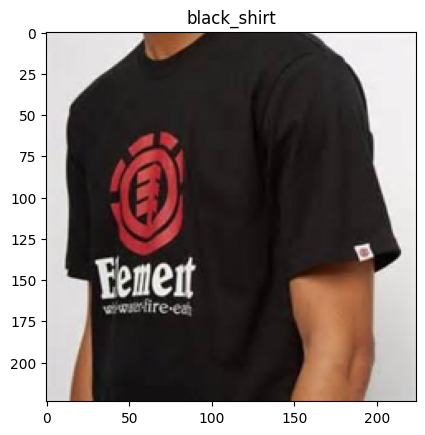

In [34]:
import random
import matplotlib.pyplot as plt

ix = random.randint(0, len(train_imgs))
img, label = train_imgs[ix], train_labels[ix]

plt.imshow(img)
plt.title(classes[label])
plt.show()

In [42]:
print(img.shape)
print(img.dtype)

(224, 224)
float64


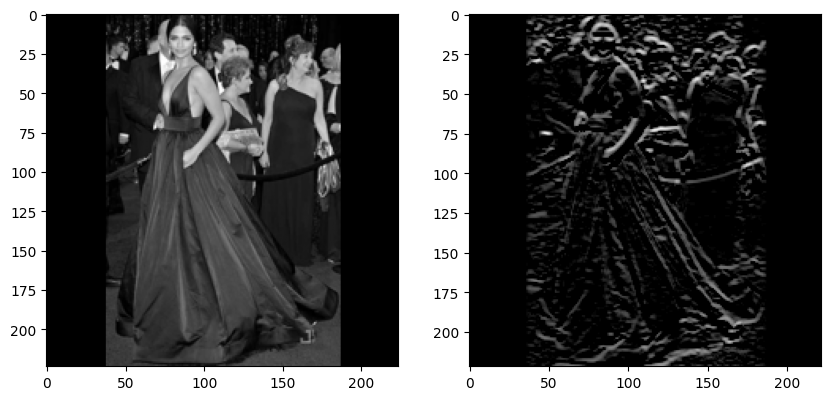

In [46]:
import numpy as np
import scipy.signal
from skimage import color
from skimage import exposure

img = color.rgb2gray(img)

kernel = np.array([[1,1,1],
                   [0,0,0],
                   [-1,-1,-1]])

edges = scipy.signal.convolve2d(img, kernel, 'valid')
edges = exposure.equalize_adapthist(edges/np.max(np.abs(edges)), clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(img, cmap=plt.cm.gray)
ax2.imshow(edges, cmap=plt.cm.gray)
plt.show()

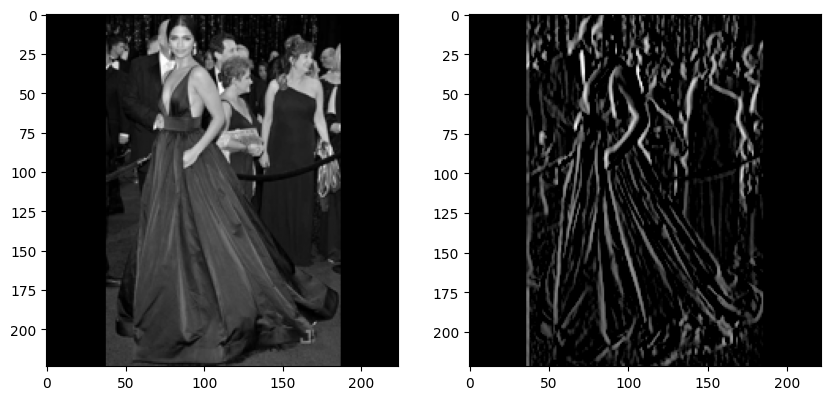

In [47]:
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

edges = scipy.signal.convolve2d(img, kernel, 'valid')
edges = exposure.equalize_adapthist(edges/np.max(np.abs(edges)), clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(img, cmap=plt.cm.gray)
ax2.imshow(edges, cmap=plt.cm.gray)
plt.show()

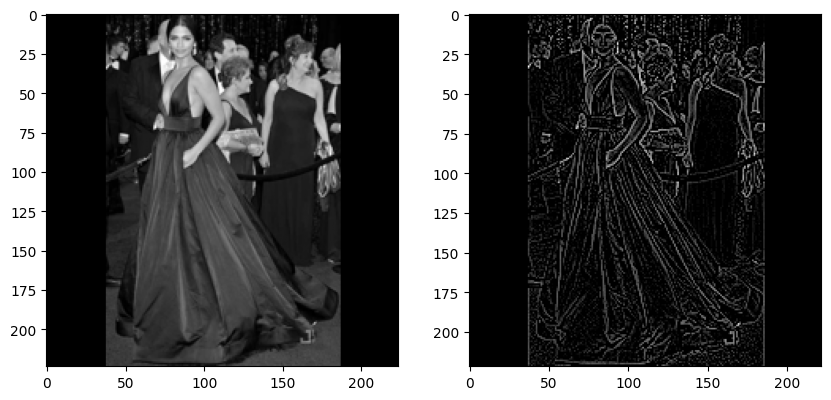

In [48]:
kernel = np.array([[0,-1,0],
                   [-1,4,-1],
                   [0,-1,0]])

edges = scipy.signal.convolve2d(img, kernel, 'valid')
edges = exposure.equalize_adapthist(edges/np.max(np.abs(edges)), clip_limit=0.03)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(img, cmap=plt.cm.gray)
ax2.imshow(edges, cmap=plt.cm.gray)
plt.show()

Converitmos a tensores las imagenes para un mejor trabajo

In [54]:
img = train_imgs[0]

if len(img.shape) == 2:  # si es gris
    img = np.stack([img,img,img], axis=-1)

img_tensor = torch.from_numpy(img / 255.0)
img_tensor = img_tensor.permute(2,0,1).unsqueeze(0).float()

print(img_tensor.shape , img_tensor.dtype)

torch.Size([1, 3, 224, 224]) torch.float32


In [55]:
# aplicamos 10 filtros de tamaño 3x3

conv = torch.nn.Conv2d(in_channels = 3, out_channels = 10, kernel_size = 3)

output = conv(img_tensor)

# dimensiones: (N, #filtros, H', W')
output.shape

torch.Size([1, 10, 222, 222])

## Capas de *Pooling*

Si bien hemos visto que jugando con los tamaños del filtro, *stride* y *padding* podemos controlar el tamaño de los mapas generados por las capas convolucionales, es también común el uso de capas *pooling* para reducir los mapas de características.

![](https://miro.medium.com/max/1456/1*WvHC5bKyrHa7Wm3ca-pXtg.gif)

Estas capas también aplican un filtro sobre su entrada, pero en este caso es un solo filtro que además no tiene parámetros sino que aplica una función predeterminada en su campo receptivo (mínimo, máximo, promedio, etc). La idea detrás del uso de este tipo de capas es la de reducir la resolución de los mapas de características, reduciendo así el coste computacional para entrenar la `red neuronal`, pero manteniendo las características importantes para el reconocimiento de patrones.

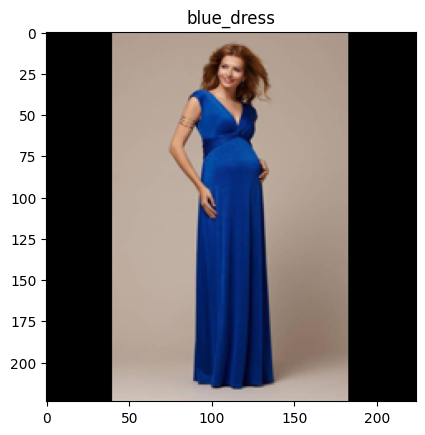

In [56]:
ix = random.randint(0, len(train_imgs))
img, label = train_imgs[ix], train_labels[ix]

plt.imshow(img)
plt.title(classes[label])
plt.show()